<a href="https://colab.research.google.com/github/KAREN154/PlantPathoDetect-/blob/main/Potato_Classification_Inception_%26_DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow.keras.applications import InceptionV3
import tensorflow as tf
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


####Building A CNN Model to Classify Tomato Images
>Tomato plants can exhibit various diseases and deficiencies that affect crop yield and quality. Accurately categorizing tomato plant conditions through leaf images is essential for effective crop management and disease control. By leveraging CNNs, the classification process can be automated, significantly improving the efficiency and accuracy of disease detection and plant health monitoring strategies.
CNNs excel at image analysis and feature extraction, allowing them to capture intricate details and patterns from tomato leaf images in the dataset.

**The convolutional layers in CNNs are able to identify:**
- Leaf color variations
- Spot patterns and lesions
- Texture changes
- Leaf venation patterns
- Disease-specific markings
- Nutrient deficiency symptoms

>These features enable the network to learn and distinguish between different tomato plant conditions. The pooling layers nested throughout the architecture down-sample the produced feature maps, allowing models to generalize leaf characteristics across different:

- Lighting conditions
- Leaf orientations
- Growth stages
- Image angles
- Environmental factors

Found 17106 images belonging to 3 classes.
Found 1282 images belonging to 3 classes.
Epoch 1/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 474s 872ms/step - accuracy: 0.7643 - loss: 0.7149 - val_accuracy: 0.9275 - val_loss: 0.2196 - learning_rate: 0.0010
Epoch 2/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 398s 744ms/step - accuracy: 0.8766 - loss: 0.3161 - val_accuracy: 0.9181 - val_loss: 0.2041 - learning_rate: 0.0010
Epoch 3/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 440s 741ms/step - accuracy: 0.8762 - loss: 0.3079 - val_accuracy: 0.9111 - val_loss: 0.2088 - learning_rate: 0.0010
Epoch 4/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 397s 742ms/step - accuracy: 0.9110 - loss: 0.2331 - val_accuracy: 0.9345 - val_loss: 0.1782 - learning_rate: 3.0000e-04
Epoch 5/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 397s 741ms/step - accuracy: 0.9151 - loss: 0.2305 - val_accuracy: 0.9321 - val_loss: 0.1728 - learning_rate: 3.0000e-04
Epoch 6/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 398s 744ms/step - accuracy: 0.9086 - loss: 0.2346 - val_accuracy: 0.9368 - val_loss: 0.1721 -

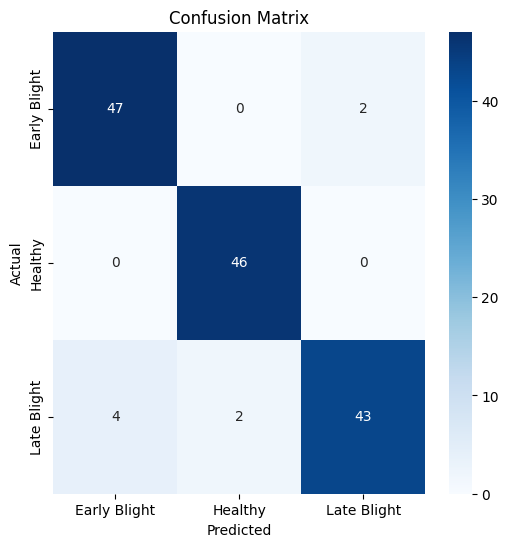

              precision    recall  f1-score   support

Early Blight       0.92      0.96      0.94        49
     Healthy       0.96      1.00      0.98        46
 Late Blight       0.96      0.88      0.91        49

    accuracy                           0.94       144
   macro avg       0.95      0.95      0.94       144
weighted avg       0.94      0.94      0.94       144



In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class FastInceptionV3:
    def __init__(self, input_shape=(128, 128, 3), num_classes=3):  # Reduced input size
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.history = None

    def build_model(self):
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=self.input_shape)

        # Freeze base model layers to speed up training
        for layer in base_model.layers:
            layer.trainable = False

        # Custom layers (Reduced complexity)
        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(128, activation='relu')(x)  # Reduced from 256 to 128
        x = Dropout(0.2)(x)  # Reduced dropout
        predictions = Dense(self.num_classes, activation='softmax')(x)

        self.model = Model(inputs=base_model.input, outputs=predictions)

        self.model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

    def train_model(self, train_dir, val_dir, batch_size=32, epochs=3):  # Lower batch, fewer epochs
        if self.model is None:
            self.build_model()

        IMAGE_SIZE = self.input_shape[:2]

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            width_shift_range=0.05,  # Reduced for speed
            height_shift_range=0.05,
            horizontal_flip=True
        )
        val_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical'
        )
        val_generator = val_datagen.flow_from_directory(
            val_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical'
        )

        if train_generator.num_classes != self.num_classes:
            raise ValueError(f"Dataset has {train_generator.num_classes} classes, but model expects {self.num_classes}")

        early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=1, factor=0.3, min_lr=1e-5)

        self.history = self.model.fit(
            train_generator,
            epochs=epochs,
            validation_data=val_generator,
            callbacks=[early_stopping, reduce_lr]

        )

    def evaluate_model(self, test_dir, batch_size=32):
        if self.model is None:
            raise ValueError("Build and train the model first.")

        IMAGE_SIZE = self.input_shape[:2]
        test_datagen = ImageDataGenerator(rescale=1./255)

        test_generator = test_datagen.flow_from_directory(
            test_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical', shuffle=False
        )

        test_loss, test_accuracy = self.model.evaluate(test_generator)
        print(f'Test Accuracy: {test_accuracy:.2f}')
        return test_loss, test_accuracy

    def plot_confusion_matrix(self, test_dir, batch_size=32):
        if self.model is None:
            raise ValueError("Train the model first.")

        IMAGE_SIZE = self.input_shape[:2]
        test_datagen = ImageDataGenerator(rescale=1./255)

        test_generator = test_datagen.flow_from_directory(
            test_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical', shuffle=False
        )

        # Get true labels and predictions
        true_labels = test_generator.classes
        predictions = self.model.predict(test_generator)
        predicted_labels = np.argmax(predictions, axis=1)

        # Compute confusion matrix
        cm = confusion_matrix(true_labels, predicted_labels)
        class_labels = list(test_generator.class_indices.keys())

        # Plot confusion matrix
        plt.figure(figsize=(6,6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

        # Print classification report
        print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Instantiate and run the optimized model
fast_model = FastInceptionV3()

# Build the model
fast_model.build_model()

# Define directories
train_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Train_augmented'
val_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Val'
test_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Test'

# Train with optimized parameters (should finish within ~1 hour on CPU)
fast_model.train_model(train_dir, val_dir, batch_size=32, epochs=8)

# Evaluate the model
test_loss, test_accuracy = fast_model.evaluate_model(test_dir)

# Plot confusion matrix
fast_model.plot_confusion_matrix(test_dir)


In [ ]:
# Instantiate the model
inception_model = InceptionV3Model()

In [ ]:
fast_model.model.save('Potato_inception_model.h5')


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

class OptimizedDenseNet121Model:
    def __init__(self, input_shape=(128, 128, 3), num_classes=3):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.history = None

    def build_model(self):
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=self.input_shape)
        base_model.trainable = False  # Freeze all layers

        x = GlobalAveragePooling2D()(base_model.output)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.3)(x)
        predictions = Dense(self.num_classes, activation='softmax')(x)

        self.model = Model(inputs=base_model.input, outputs=predictions)
        self.model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

    def train_model(self, train_dir, val_dir, batch_size=32, epochs=3):
        IMAGE_SIZE = self.input_shape[:2]

        train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
        val_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical')
        val_generator = val_datagen.flow_from_directory(
            val_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical')

        early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=1, factor=0.5)

        self.history = self.model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=epochs,
            callbacks=[early_stopping, reduce_lr]
        )

    def evaluate_model(self, test_dir, batch_size=32):
        IMAGE_SIZE = self.input_shape[:2]
        test_datagen = ImageDataGenerator(rescale=1./255)
        test_generator = test_datagen.flow_from_directory(
            test_dir, target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='categorical')

        test_loss, test_accuracy = self.model.evaluate(test_generator)
        print(f'Test Accuracy: {test_accuracy:.2f}')
        return test_loss, test_accuracy

# Instantiate model
densenet_model = OptimizedDenseNet121Model()
densenet_model.build_model()

# Define dataset directories
train_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Train_augmented'
val_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Val'
test_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Test'

# Train the model
densenet_model.train_model(train_dir, val_dir, batch_size=32, epochs=3)

# Evaluate the model
densenet_model.evaluate_model(test_dir)


Found 17106 images belonging to 3 classes.
Found 1282 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 2975s 6s/step - accuracy: 0.7956 - loss: 0.5043 - val_accuracy: 0.9657 - val_loss: 0.0973 - learning_rate: 5.0000e-04
Epoch 2/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 707s 1s/step - accuracy: 0.9307 - loss: 0.1841 - val_accuracy: 0.9672 - val_loss: 0.0835 - learning_rate: 5.0000e-04
Epoch 3/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 714s 1s/step - accuracy: 0.9413 - loss: 0.1508 - val_accuracy: 0.9782 - val_loss: 0.0594 - learning_rate: 5.0000e-04
Found 144 images belonging to 3 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9857 - loss: 0.0484
Test Accuracy: 0.98


(0.06242915615439415, 0.9791666865348816)

In [8]:
# Save the model using the 'model' attribute
densenet_model.model.save('Potato_densenet_model.h5')

In [12]:
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('Potato_densenet_model.h5')

# Define image size and batch size
# Change IMAGE_SIZE to match the model's input shape
IMAGE_SIZE = (128, 128)  # Corrected image size
BATCH_SIZE = 32

# Define data generator
test_datagen = ImageDataGenerator(rescale=1./255)

# Define test directory
test_dir = '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Test'
# Corn (Maize)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
# Make predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Compute F1 score
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f'Weighted F1 Score: {f1:.2f}')

# Print classification report
report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
print(report)

Found 144 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Weighted F1 Score: 0.98
              precision    recall  f1-score   support

Early Blight       0.98      0.96      0.97        49
     Healthy       0.98      1.00      0.99        46
 Late Blight       0.98      0.98      0.98        49

    accuracy                           0.98       144
   macro avg       0.98      0.98      0.98       144
weighted avg       0.98      0.98      0.98       144

